In [2]:
%load_ext autoreload
%autoreload 2

import materialdatabase as mdb
from materialdatabase.processing.utils.math import mean_relative_absolute_error as mre

from hybridmag.utils import comsol_interface as comsol

from utils import material_processing as materials
from utils import infinite_cylinder as ic
from utils.physics import *
from utils.maths import *
from meta import paths
from meta.plot_settings import colors

import matplotlib
from matplotlib import pyplot as plt

path2simulations = paths.simulation_data
path2plots = paths.grafics

# -------------------------
# Helpful definitions
# -------------------------
cm = 1 / 2.54

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Bitstream Vera Sans", "DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}\usepackage{siunitx}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### IC vs. 2D FEM

In [3]:
# -------------------------
# Geometry definition
# Relevant geometric parameters of a PQ4040 core
# -------------------------
R = 0.0149/2  # radius
H_w = 0.0298 # height of winding window

#### Non-linear material data

In [4]:
# -------------------------
# Material (nonlinear)
# -------------------------
T_c = 60

# init a material database instance
mdb_data = mdb.Data()

complex_permeability = mdb_data.get_complex_permeability(material=mdb.Material.N49,
                                                         data_source=mdb.DataSource.LEA_MTB,
                                                         pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                         probe_codes=None)

complex_permittivity = mdb_data.get_complex_permittivity(material=mdb.Material.N49,
                                                         data_source=mdb.DataSource.LEA_MTB)

c:\users\tpiepe\repositories\materialdatabase\materialdatabase\processing\utils\empirical.py:136: RuntimeWarning: invalid value encountered in log
  return np.log(enhanced_steinmetz_qT(fTb, alpha, beta, k_b, k_f, k_alpha2, c_0, c_1, c_2))
f_min: 107760.0
f_max: 1350260.0



MRE (IC): 0.84 %
MRE (static): 47.87 %


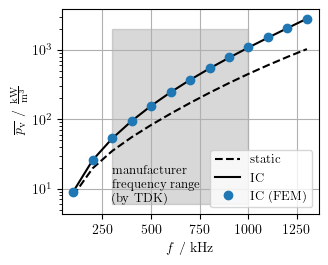

In [5]:
df_2D_FEM = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("IC_model/results_non_linear.txt"),
    header=["f", "PF_dim", "b_mean", "p_v", "p_mag", "p_el"]
)

# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
b_common = np.linspace(0, 0.2, 50)
pv_IC, pv_static = [], []
for index, row in df_2D_FEM.iterrows():
    f = row["f"] * 1000
    b_mean = row["b_mean"] / 1000

    # -------------------------
    # Material fit at temperature and frequency
    # -------------------------
    # Permeability:
    mu_real, mu_imag = complex_permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f,
                                                                                   T_op=T_c,
                                                                                   b_vals=np.linspace(0, 0.2, 50))
    # an interpolation in terms of the magnetic field h is needed:
    mu_h = materials.mu_h_from_mu_b((mu_real - j * mu_imag) * mu_0, b_common)

    # Permittivity:
    eps_real, eps_imag = complex_permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=T_c)
    eps = epsilon_0 * (eps_real - j * eps_imag)

    # -------------------------
    # IC model
    # -------------------------
    pv_IC.append(ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=eps, mu_of_h=mu_h))

    # -------------------------
    # Static model
    # -------------------------
    pv_static.append(ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=epsilon_0, mu_of_h=mu_h))

# -------------------------
# Plots
# -------------------------
fig, ax = plt.subplots(figsize=(8.6 * cm, 7 * cm))

ax.semilogy(df_2D_FEM["f"], np.array(pv_static) / 1000, "--", label=r"static", color="black")
ax.semilogy(df_2D_FEM["f"], np.array(pv_IC) / 1000, "-", label=r"IC", color="black")
ax.semilogy(df_2D_FEM["f"], df_2D_FEM["p_v"] / 1000, "o", label=f"IC (FEM)")

# Error metrics
mre_IC = mre(df_2D_FEM["p_v"], np.array(pv_IC))
mre_static = mre(df_2D_FEM["p_v"], np.array(pv_static))
print(f"MRE (IC): {np.round(mre_IC * 100, decimals=2)} %")
print(f"MRE (static): {np.round(mre_static*100, decimals=2)} %")


# -------------------------
# Add shaded region (manufacturer frequency range)
# -------------------------
f_min_kHz = 300
f_max_kHz = 1000
y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)
ax.text(
    f_min_kHz,
    y_min,
    "manufacturer\nfrequency range\n(by TDK)",
    ha='left', va='bottom',
    fontsize=9, color='black'
)

# -------------------------
# Final plot settings
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

ax.legend(ncols=1, loc="lower right", fontsize=9)

ax.grid()
fig.align_labels()
plt.tight_layout()

plt.show()

### 3D FEM simulations vs. IC model

Computation:

In [6]:
# -------------------------
# Load FEM results and add the analytically computed solutions
# -------------------------
# auxiliary information - must equal settings in the FEM simulations:
b_mean = 50e-3
d_g = np.array([0, 1.8, 1.8, 1.8]) * 1e-3
no_gaps = ["0", "1", "2", "3"]

df_3D_FEM_pv_center = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("PQ_model/FEM_vs_IC/core_losses.txt"),
    header=["f"] + no_gaps
)

# use the center leg volume (incorporating the air gap lengths) to calculate the average loss density in the center leg
V_center = (H_w-d_g) * np.pi * R**2
df_3D_FEM_pv_center[no_gaps] = df_3D_FEM_pv_center[no_gaps].div(V_center, axis=1)


# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
for index, row in df_3D_FEM_pv_center.iterrows():
    f = row["f"]

    # -------------------------
    # Material fit at temperature and frequency
    # -------------------------
    # Permeability:
    mu_real, mu_imag = complex_permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f,
                                                                                   T_op=T_c,
                                                                                   b_vals=np.linspace(0, 0.2, 50))
    # an interpolation in terms of the magnetic field h is needed:
    mu_h = materials.mu_h_from_mu_b((mu_real - j * mu_imag) * mu_0, b_common)

    # Permittivity:
    eps_real, eps_imag = complex_permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=T_c)
    eps = epsilon_0 * (eps_real - j * eps_imag)

    # -------------------------
    # IC model
    # -------------------------
    df_3D_FEM_pv_center.loc[index, "pv_IC"]  = ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=eps, mu_of_h=mu_h)

    # -------------------------
    # Static model
    # -------------------------
    df_3D_FEM_pv_center.loc[index, "pv_static"] = ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=epsilon_0, mu_of_h=mu_h)


f_min: 107760.0
f_max: 1350260.0



Plotting:

0: MRE (IC)    : 0.9 %
0: MRE (static): 50.1 %
1: MRE (IC)    : 4.9 %
1: MRE (static): 47.4 %
2: MRE (IC)    : 8.5 %
2: MRE (static): 45.6 %
3: MRE (IC)    : 10.8 %
3: MRE (static): 44.5 %


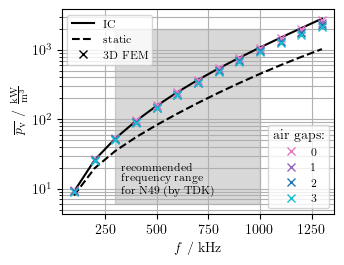

In [11]:
# Recommended frequency range
f_min_kHz = 300
f_max_kHz = 1000

fig, ax = plt.subplots(figsize=(9 * cm, 7 * cm))
comsol_color = '0.8'

# Create mask for recommended frequency range
mask = (df_3D_FEM_pv_center["f"] / 1000 >= f_min_kHz) & (df_3D_FEM_pv_center["f"] / 1000 <= f_max_kHz)

# First plot the analytically calculated loss densities
ax.semilogy(df_3D_FEM_pv_center["f"] / 1000, df_3D_FEM_pv_center["pv_IC"] / 1000, "-", color="black")
ax.semilogy(df_3D_FEM_pv_center["f"] / 1000, df_3D_FEM_pv_center["pv_static"] / 1000, "--", color="black")

# Second plot the FEM-simulated loss densities on top
for index, col in enumerate(no_gaps):
    ax.semilogy(df_3D_FEM_pv_center["f"] / 1000, df_3D_FEM_pv_center[col] / 1000, "x", label=f"{col}", color=colors[index])

    # Calculate MRE vs. FEM within recommended frequency range
    mre_ic = mre(x=df_3D_FEM_pv_center.loc[mask, col], x_est=df_3D_FEM_pv_center.loc[mask, 'pv_IC'])
    mre_static = mre(x=df_3D_FEM_pv_center.loc[mask, col], x_est=df_3D_FEM_pv_center.loc[mask, 'pv_static'])

    # Print MRE
    print(f"{col}: MRE (IC)    : {np.round(mre_ic * 100, decimals=1)} %")
    print(f"{col}: MRE (static): {np.round(mre_static*100, decimals=1)} %")


# -------------------------
# Add shaded region
# -------------------------

y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)

ax.text(
    f_min_kHz * 1.1,
    y_min * 1.3,
    "recommended\nfrequency range\nfor N49 (by TDK)",
    ha='left', va='bottom',
    fontsize=8, color='black',
    # bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3')
)


# -------------------------
# Final plot touches
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

line1 = matplotlib.lines.Line2D([0], [0], label=r"IC", color='k')
line2 = matplotlib.lines.Line2D([0], [0], label=r"static", color='k', linestyle="--")
line3 = matplotlib.lines.Line2D([0], [0], label=r"3D FEM", color='k', marker="x", linestyle="")
legend1 = ax.legend(handles=[line1, line2, line3], ncol=1, loc="upper left", fontsize=8)

ax.legend(ncols=1, loc="lower right", title="air gaps:", fontsize=8)
plt.gca().add_artist(legend1)

ax.grid(True, which="both")
fig.align_labels()
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_nonlinear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_nonlinear.png"))
plt.show()

### FEM vs. IC: Field comparison

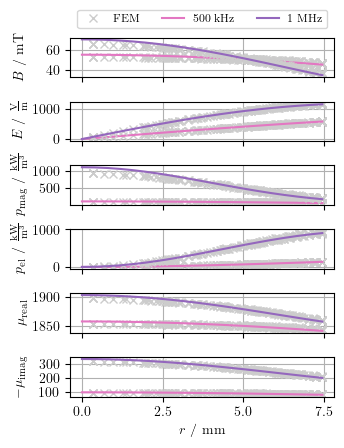

In [8]:
fig, ax = plt.subplots(6, figsize=(9*cm, 12*cm), sharex="all")
FEM_marker = "x"

# downsampling of the FEM plots to avoid too many data points and large PDFs
n_sample = 5

# frequencies at which FEM simulation data is available
fs = [500e3, 1e6]
fs_labels = ["500 kHz", "1 MHz"]

# -------------------------
# Iterate over frequencies
# -------------------------
for i, f in enumerate(fs):
    FEM_label = "FEM" if i == 0 else None

    # -------------------------
    # Fields from 3D FEM simulation (in Comsol)
    # -------------------------
    # Magnetic flux density from Comsol
    x_B, y_B, B = comsol.read_comsol_2d_circle_field(
        link=path2simulations.joinpath(f"PQ_model/FEM_vs_IC/fields/{int(f)}/MagB_horizontal.txt"),
        field_name="MagB",
        R=R
    )
    r_B = np.sqrt(x_B**2 + y_B**2)
    ax[0].plot(1000*r_B[::n_sample], B[::n_sample]*1000, FEM_marker, color=comsol_color, label=FEM_label)

    # Electric field from Comsol
    x_E, y_E, E = comsol.read_comsol_2d_circle_field(
        link=path2simulations.joinpath(f"PQ_model/FEM_vs_IC/fields/{int(f)}/MagE_horizontal.txt"),
        field_name="MagE",
        R=R
    )
    r_E = np.sqrt(x_E**2 + y_E**2)
    ax[1].plot(1000*r_E[::n_sample], E[::n_sample], FEM_marker, color=comsol_color)

    # Magnetic loss density from Comsol
    x_p_mag, y_p_mag, p_mag = comsol.read_comsol_2d_circle_field(
        link=path2simulations.joinpath(f"PQ_model/FEM_vs_IC/fields/{int(f)}/p_mag_horizontal.txt"),
        field_name="p_mag",
        R=R
    )
    r_p_mag = np.sqrt(x_p_mag**2 + y_p_mag**2)
    ax[2].plot(1000*r_p_mag[::n_sample], p_mag[::n_sample]/1000, FEM_marker, color=comsol_color)

    # Electric loss density from Comsol
    x_p_el, y_p_el, p_el = comsol.read_comsol_2d_circle_field(
        link=path2simulations.joinpath(f"PQ_model/FEM_vs_IC/fields/{int(f)}/p_el_horizontal.txt"),
        field_name="p_el",
        R=R
    )
    r_p_el = np.sqrt(x_p_el**2 + y_p_el**2)
    ax[3].plot(1000*r_p_el[::n_sample], p_el[::n_sample]/1000, FEM_marker, color=comsol_color)

    # Real permeability from Comsol
    x_mu_real, y_mu_real, mu_real = comsol.read_comsol_2d_circle_field(
        link=path2simulations.joinpath(f"PQ_model/FEM_vs_IC/fields/{int(f)}/mu_real_horizontal.txt"),
        field_name="mu_real",
        R=R)
    # 1d plot in dependency of the radius
    r_mu_real_comsol = np.sqrt(x_mu_real ** 2 + y_mu_real ** 2)
    ax[4].plot(1000 * r_mu_real_comsol[::n_sample], mu_real[::n_sample], FEM_marker, color=comsol_color)

    # Imaginary permeability from Comsol
    x_mu_imag, y_mu_imag, mu_imag = comsol.read_comsol_2d_circle_field(
        link=path2simulations.joinpath(f"PQ_model/FEM_vs_IC/fields/{int(f)}/mu_imag_horizontal.txt"),
        field_name="mu_imag",
        R=R)
    # 1d plot in dependency of the radius
    r_mu_imag_comsol = np.sqrt(x_mu_imag ** 2 + y_mu_imag ** 2)
    ax[5].plot(1000 * r_mu_imag_comsol[::n_sample], -mu_imag[::n_sample], FEM_marker, color=comsol_color)



    # -------------------------
    # IC model
    # -------------------------

    # Material fit at temperature and frequency

    # Permeability:
    mu_real, mu_imag = complex_permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f,
                                                                                   T_op=T_c,
                                                                                   b_vals=np.linspace(0, 0.2, 50))
    # an interpolation in terms of the magnetic field h is needed:
    mu_h = materials.mu_h_from_mu_b((mu_real - j * mu_imag) * mu_0, b_common)

    # Permittivity:
    eps_real, eps_imag = complex_permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=T_c)
    eps = epsilon_0 * (eps_real - j * eps_imag)

    # IC model
    r_, H_, E_ = ic.r_h_e_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=eps, mu_of_h=mu_h)

    # Loss densities from fields
    pv_mag_ic = f_pv_mag(f, mu_h(abs(H_)).imag, np.abs(H_))
    pv_el_ic = f_pv_el(f, eps.imag, np.abs(E_))

    # Plot IC fields
    ax[0].plot(1000*r_, np.abs(mu_h(abs(H_)) * H_)*1000, label=fs_labels[i], color=colors[i])
    ax[1].plot(1000*r_, np.abs(E_), color=colors[i])
    ax[2].plot(1000*r_, pv_mag_ic/1000, color=colors[i])
    ax[3].plot(1000*r_, pv_el_ic/1000, color=colors[i])
    ax[4].plot(1000*r_, mu_h(abs(H_)).real/mu_0, color=colors[i])
    ax[5].plot(1000*r_, -mu_h(abs(H_)).imag/mu_0, color=colors[i])


# -------------------------
# Plot settings
# -------------------------
ax[0].set_ylabel(r"$B$ / mT")
ax[1].set_ylabel(r"$E$ / $\frac{\mathrm{V}}{\mathrm{m}}$")
ax[2].set_ylabel(r"$p_\mathrm{mag}$ / $\frac{\mathrm{kW}}{\mathrm{m^3}}$")
ax[3].set_ylabel(r"$p_\mathrm{el}$ / $\frac{\mathrm{kW}}{\mathrm{m^3}}$")
ax[4].set_ylabel(r"$\mu_\mathrm{real}$")
ax[5].set_ylabel(r"$-\mu_\mathrm{imag}$")
ax[5].set_xlabel(r"$r$ / mm")
ax[0].legend(ncols=3, loc='upper center', bbox_to_anchor=[0.5, 1.85], fontsize=8)
ax[5].set_xticks([0, 2.5, 5, 7.5])

for a in ax:
    a.grid()

fig.align_labels()
plt.subplots_adjust(wspace=0, hspace=0.1)
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_fields_nonlinear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_fields_nonlinear.png"))
plt.show()
